# Task 2: Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_path = "../data/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx"

state_txn_users = pd.read_excel(file_path, sheet_name="State_Txn and Users")
state_txn_split = pd.read_excel(file_path, sheet_name="State_TxnSplit")
state_device = pd.read_excel(file_path, sheet_name="State_DeviceData")
district_txn_users = pd.read_excel(file_path, sheet_name="District_Txn and Users")
district_demo = pd.read_excel(file_path, sheet_name="District Demographics")

print("Datasets loaded successfully!")

Datasets loaded successfully!


## Task 2.1: Analyze transaction trends over the years for each state

In [5]:
transaction_trend = (
    state_txn_users
    .groupby(["State", "Year"])[["Transactions", "Amount (INR)"]]
    .sum()
    .reset_index()
)

transaction_trend   # Total Transactions and Amount by State and Year

,State,Year,Transactions,Amount (INR)
0,Andaman & Nicobar Islands,2018,58021,1.890761e+08
1,Andaman & Nicobar Islands,2019,133104,4.734648e+08
2,Andaman & Nicobar Islands,2020,446274,1.296423e+09
3,Andaman & Nicobar Islands,2021,586166,1.682854e+09
4,Andhra Pradesh,2018,77779112,1.220720e+11
...,...,...,...,...
139,Uttarakhand,2021,44608834,7.727901e+10
140,West Bengal,2018,120011635,1.115887e+11
141,West Bengal,2019,257900590,2.660145e+11
142,West Bengal,2020,304222327,5.527316e+11


In [7]:
top_5_states = (
    state_txn_users
    .groupby("State")["Transactions"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_5_states     # Top 5 States with Highest Transaction Volume

State
Karnataka         2981044533
Maharashtra       2833670154
Telangana         2347430243
Andhra Pradesh    1781091169
Rajasthan         1382918930
Name: Transactions, dtype: int64

In [9]:
bottom_5_states = (
    state_txn_users
    .groupby("State")["Transactions"]
    .sum()
    .sort_values()
    .head(5)
)

bottom_5_states    # Top 5 States with Lowest Transaction Volume

State
Lakshadweep                    71610
Andaman & Nicobar Islands    1223565
Ladakh                       1880109
Mizoram                      2162776
Meghalaya                    5648913
Name: Transactions, dtype: int64

## Task 2.2: Most Common Transaction Type in each State and Quarter

In [ ]:
most_common_transaction = (
    state_txn_split
    .sort_values("Transactions", ascending=False)
    .groupby(["State", "Year", "Quarter"])
    .first()
    .reset_index()
)

most_common_transaction[
    ["State", "Year", "Quarter", "Transaction Type", "Transactions"]
]                                                                           # Most Common Transaction Type in each State and Quarter

,State,Year,Quarter,Transaction Type,Transactions
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200
1,Andaman & Nicobar Islands,2018,2,Recharge & bill payments,6735
2,Andaman & Nicobar Islands,2018,3,Recharge & bill payments,8636
3,Andaman & Nicobar Islands,2018,4,Recharge & bill payments,11517
4,Andaman & Nicobar Islands,2019,1,Recharge & bill payments,15263
...,...,...,...,...,...
499,West Bengal,2020,2,Peer-to-peer payments,24855687
500,West Bengal,2020,3,Peer-to-peer payments,37556349
501,West Bengal,2020,4,Peer-to-peer payments,46437233
502,West Bengal,2021,1,Peer-to-peer payments,53869075


## Task 2.3: Device Brand with Highest Number of Registered Users

In [11]:
top_device_brand = (
    state_device
    .sort_values("Registered Users", ascending=False)
    .groupby("State")
    .first()
    .reset_index()
)

top_device_brand[
    ["State", "Brand", "Registered Users"]
]

,State,Brand,Registered Users
0,Andaman & Nicobar Islands,Vivo,15056
1,Andhra Pradesh,Xiaomi,4937684
2,Arunachal Pradesh,Vivo,63439
3,Assam,Xiaomi,909274
4,Bihar,Xiaomi,4268361
5,Chandigarh,Xiaomi,101761
6,Chhattisgarh,Vivo,1169224
7,Dadra & Nagar Haveli and Daman & Diu,Vivo,87001
8,Delhi,Xiaomi,2731995
9,Goa,Xiaomi,152107


## Task 2.4: Top District per State based on Population

In [12]:
top_district_population = (
    district_demo
    .sort_values("Population", ascending=False)
    .groupby("State")
    .first()
    .reset_index()
)

top_district_population[
    ["State", "District", "Population"]
]

,State,District,Population
0,Andaman & Nicobar Islands,South Andaman,238142
1,Andhra Pradesh,East Godavari,5151549
2,Arunachal Pradesh,Papum Pare,176385
3,Assam,Nagaon,2826006
4,Bihar,Patna,5772804
5,Chandigarh,Chandigarh,1055450
6,Chhattisgarh,Raipur,2160876
7,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,343709
8,Delhi,North West Delhi,3656539
9,Goa,North Goa,817761


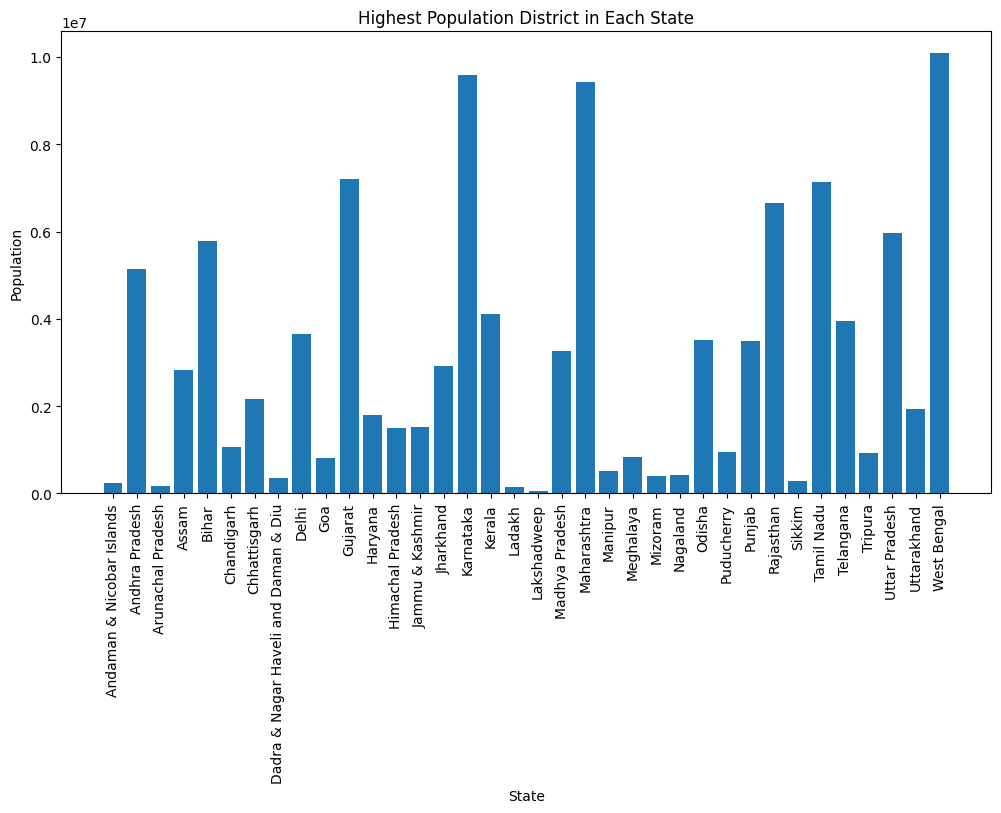

In [13]:
plt.figure(figsize=(12,6))

plt.bar(
    top_district_population["State"],
    top_district_population["Population"]
)

plt.xticks(rotation=90)

plt.title("Highest Population District in Each State")

plt.xlabel("State")

plt.ylabel("Population")

plt.show()

## Task 2.5: Average Transaction Value (ATV) for each State

In [16]:
state_atv = (
    state_txn_users
    .groupby("State")["ATV (INR)"]
    .mean()
    .reset_index()
)

state_atv

,State,ATV (INR)
0,Andaman & Nicobar Islands,3159.266422
1,Andhra Pradesh,1748.091476
2,Arunachal Pradesh,2638.323985
3,Assam,2008.495656
4,Bihar,2023.316978
5,Chandigarh,2113.797075
6,Chhattisgarh,1650.818617
7,Dadra & Nagar Haveli and Daman & Diu,1487.395599
8,Delhi,1589.839307
9,Goa,1895.258549


In [ ]:
state_atv.sort_values(
    by="ATV (INR)",
    ascending=False
).head(5)   # Top 5 Highest ATV States

,index,State,ATV (INR)
0,17,Ladakh,3408.222984
1,0,Andaman & Nicobar Islands,3159.266422
2,23,Mizoram,2927.517802
3,18,Lakshadweep,2776.118701
4,2,Arunachal Pradesh,2638.323985


In [22]:
state_atv.sort_values(
    by="ATV (INR)",
    ascending=True
).head(5)   # Top 5 Lowest ATV States

,State,ATV (INR)
35,West Bengal,1373.600590
25,Odisha,1428.137367
7,Dadra & Nagar Haveli and Daman & Diu,1487.395599
20,Maharashtra,1516.361820
15,Karnataka,1517.392249


## Task 2.6: Analyze App Usage Trends

In [24]:
app_usage = (
    state_txn_users
    .groupby(
        ["State", "Year", "Quarter"]
    )["App Opens"]
    .sum()
    .reset_index()
)

app_usage   # Total App Opens by State, Year and Quarter

,State,Year,Quarter,App Opens
0,Andaman & Nicobar Islands,2018,1,0
1,Andaman & Nicobar Islands,2018,2,0
2,Andaman & Nicobar Islands,2018,3,0
3,Andaman & Nicobar Islands,2018,4,0
4,Andaman & Nicobar Islands,2019,1,0
...,...,...,...,...
499,West Bengal,2020,2,198589332
500,West Bengal,2020,3,246554831
501,West Bengal,2020,4,291721919
502,West Bengal,2021,1,316832674


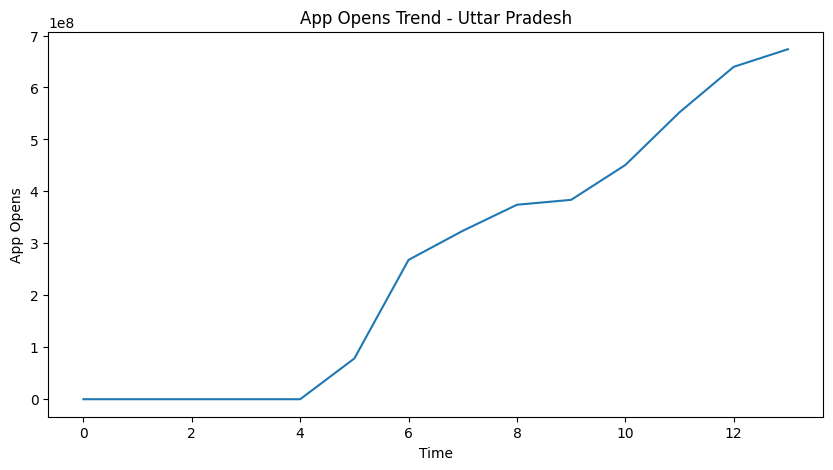

In [26]:
selected_state = "Uttar Pradesh"

state_data = state_txn_users[
    state_txn_users["State"] == selected_state
]

plt.figure(figsize=(10,5))

plt.plot(
    range(len(state_data)),
    state_data["App Opens"]
)

plt.title(f"App Opens Trend - {selected_state}")

plt.xlabel("Time")

plt.ylabel("App Opens")

plt.show()   # Line Plot for Selected State  Example: Uttar Pradesh

## Task 2.7: Distribution of Transaction Types

In [29]:
latest_year = state_txn_split["Year"].max()

latest_quarter = (
    state_txn_split[
        state_txn_split["Year"] == latest_year
    ]["Quarter"].max()
)

latest_data = state_txn_split[
    (state_txn_split["Year"] == latest_year)
    &
    (state_txn_split["Quarter"] == latest_quarter)
]     

# Most Recent Quarter Data

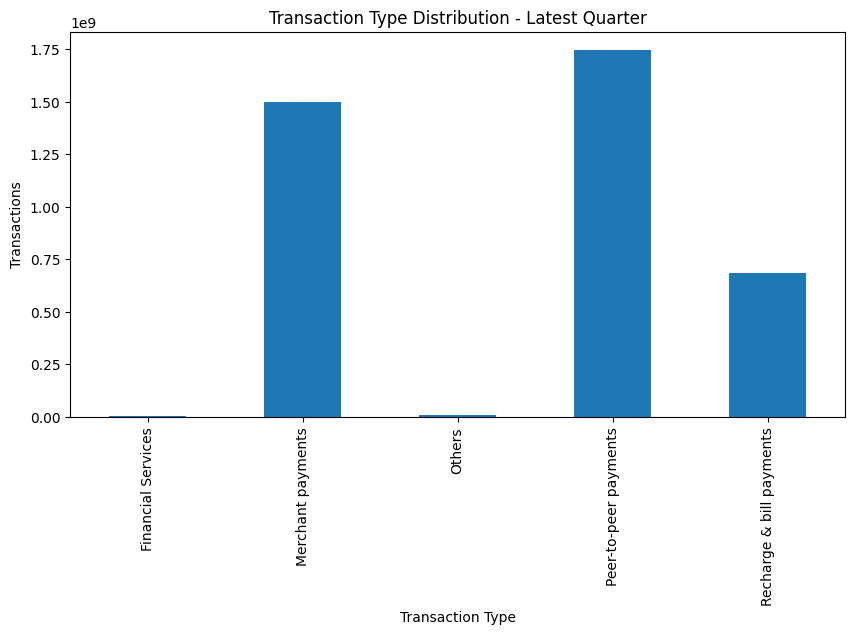

In [30]:
transaction_distribution = (
    latest_data
    .groupby("Transaction Type")["Transactions"]
    .sum()
)

transaction_distribution.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Transaction Type Distribution - Latest Quarter"
)

plt.xlabel("Transaction Type")

plt.ylabel("Transactions")

plt.show()

## Task 2.8: Unique Mapping Between District Name and District Code

In [31]:
district_mapping = (
    district_demo[
        ["District", "Code"]
    ]
    .drop_duplicates()
)

district_mapping.head()

,District,Code
0,Anantapur,AP01
1,Chittoor,AP02
2,East Godavari,AP03
3,Guntur,AP04
4,YSR,AP13


In [32]:
district_mapping.to_csv(
    "../data/district_mapping.csv",
    index=False
)

print("CSV exported successfully!")

CSV exported successfully!


In [33]:
pd.read_csv("../data/district_mapping.csv").head()

,District,Code
0,Anantapur,AP01
1,Chittoor,AP02
2,East Godavari,AP03
3,Guntur,AP04
4,YSR,AP13


# Conclusion

Task 2 completed successfully.

- Analyzed transaction trends.
- Identified most common transaction types.
- Found top device brands.
- Identified highest population districts.
- Calculated ATV.
- Analyzed app usage trends.
- Visualized transaction type distribution.
- Exported district-code mapping.